# Notebook 01 — Exploratory Data Analysis (EDA)
**Project:** Huawei Telecom Complaint Analytics & Network Intelligence Platform  
**Deliverable:** D1 — EDA Report  
**Sources:** `real_complaints.xlsx` — Sheet1 

## 1. Setup & Chargement

In [1]:
import sys, os
PROJECT_ROOT = r'C:\Users\c50057188\Desktop\PFE_Ouerghi'
sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='darkgrid')
COLORS  = sns.color_palette('husl', 12)
FIGURES = 'reports/figures'
os.makedirs(FIGURES, exist_ok=True)
os.makedirs('reports/exports', exist_ok=True)
print('Setup OK')

Setup OK


In [2]:
from src.ingestion.real_data_loader import load_all_from_excel, get_data_summary

# ── Real column names from your DCLM export ──────────────────────────────
# Sheet1: Case ID | system | case open datetime | Type | msisdn |
#         last status | Provider Group | Typologie It/network |
#         category | sub category | sub sub category |
#         province | city | Segment MSISDN CONCERN |
#         bscs_custcode | account contact name | Week
# ─────────────────────────────────────────────────────────────────────────

data       = load_all_from_excel()
complaints = data['complaints']       # Sheet1
kpi_data   = data['kpi_data_only']   # DATA sheet
kpi_voice  = data['kpi_voice_only']  # VOICE sheet

print(f'Sheet1  (complaints) : {complaints.shape}')
print(f'DATA    (sessions)   : {kpi_data.shape}')
print(f'VOICE   (sessions)   : {kpi_voice.shape}')
print()
print('Sheet1 columns:')
for col in complaints.columns:
    n_null = complaints[col].isnull().sum()
    n_uniq = complaints[col].nunique()
    print(f'  {col:<40} nulls={n_null:<5} unique={n_uniq}')

2026-05-05 07:26:07.375 | INFO     | src.ingestion.real_data_loader:load_all_from_excel:165 - Chargement de : data\raw\real_complaints.xlsx
2026-05-05 07:26:11.084 | INFO     | src.ingestion.real_data_loader:load_all_from_excel:167 -   Feuilles trouvées : ['Sheet1', 'DATA', 'VOICE']
2026-05-05 07:26:31.487 | INFO     | src.ingestion.real_data_loader:_load_sheet1:241 -   Sheet1 ('Sheet1'): 25,727 lignes × 17 colonnes
2026-05-05 07:26:31.488 | INFO     | src.ingestion.real_data_loader:_load_sheet1:243 -   Colonnes : ['Case ID', 'system', 'case open datetime', 'Type', 'msisdn', 'last status', 'Provider Group', 'typologie It/network', 'category', 'sub category', 'sub sub category', 'province', 'city', 'Segment MSISDN CONCERN', 'bscs_custcode', 'account contact name', 'Week']
2026-05-05 07:26:31.523 | INFO     | src.ingestion.real_data_loader:_apply_mapping:587 -   Supprimé (RGPD) : ['account contact name']
2026-05-05 07:26:31.524 | INFO     | src.ingestion.real_data_loader:_apply_mapping:5

Sheet1  (complaints) : (25727, 22)
DATA    (sessions)   : (3806, 13)
VOICE   (sessions)   : (3440, 13)

Sheet1 columns:
  case_id                                  nulls=0     unique=25727
  source_system                            nulls=0     unique=1
  timestamp                                nulls=0     unique=25705
  ticket_type                              nulls=0     unique=2
  msisdn                                   nulls=0     unique=22226
  resolution_status                        nulls=0     unique=14
  provider_group                           nulls=0     unique=1
  complaint_typology                       nulls=0     unique=1
  service_type                             nulls=0     unique=2
  complaint_category                       nulls=0     unique=9
  complaint_subcategory                    nulls=0     unique=20
  region                                   nulls=2375  unique=24
  city                                     nulls=2511  unique=257
  customer_segment             

## 2. Sheet1 — EDA Plaintes

### 2.1 Vue d'ensemble

In [3]:
# ── Column aliases — exactly as output by real_data_loader ───────────────
C_TIMESTAMP  = 'timestamp'
C_TYPE       = 'service_type'          # Data / Voice
C_MSISDN     = 'msisdn'
C_STATUS     = 'resolution_status'
C_PROVIDER   = 'provider_group'
C_TYPOLOGY   = 'complaint_typology'   # IT vs Network
C_CATEGORY   = 'complaint_category'    # sub category  → 'Reclamation reseau mobile data'
C_SUBCAT     = 'complaint_category'    # alias du même niveau (pour compatibilité des cells)
C_SUBSUBCAT  = 'complaint_subcategory' # sub sub category → 'Debit internet faible'
C_PROVINCE   = 'region'
C_CITY       = 'city'
C_SEGMENT    = 'customer_segment'
C_CUSTCODE   = 'customer_code'
C_WEEK       = 'week'
C_CASEID     = 'case_id'
# Already derived by loader: hour | day_of_week | month | year | date | priority

# timestamp already parsed by loader — guard in case it isn't
if C_TIMESTAMP in complaints.columns:
    complaints[C_TIMESTAMP] = pd.to_datetime(complaints[C_TIMESTAMP], errors='coerce')
    if 'hour' not in complaints.columns:
        complaints['hour']        = complaints[C_TIMESTAMP].dt.hour
        complaints['day_of_week'] = complaints[C_TIMESTAMP].dt.day_name()
        complaints['year']        = complaints[C_TIMESTAMP].dt.year
        complaints['month']       = complaints[C_TIMESTAMP].dt.month

print('=== SHEET1 — OVERVIEW ===')
print(f'Total complaints    : {len(complaints):,}')
if C_TIMESTAMP in complaints.columns:
    print(f'Period              : {complaints[C_TIMESTAMP].min().date()} → {complaints[C_TIMESTAMP].max().date()}')
print(f'Unique MSISDNs      : {complaints[C_MSISDN].nunique():,}')
print(f'Provinces / Regions : {complaints[C_PROVINCE].nunique()}')
print(f'Cities              : {complaints[C_CITY].nunique()}')
print(f'Categories          : {complaints[C_CATEGORY].nunique()}')
print(f'Sub-categories      : {complaints[C_SUBCAT].nunique()}')
print()
display(complaints.head(5))


=== SHEET1 — OVERVIEW ===
Total complaints    : 25,727
Period              : 2025-01-01 → 2025-12-03
Unique MSISDNs      : 22,226
Provinces / Regions : 24
Cities              : 257
Categories          : 9
Sub-categories      : 9



,case_id,source_system,timestamp,ticket_type,msisdn,resolution_status,provider_group,complaint_typology,service_type,complaint_category,...,city,customer_segment,customer_code,week,priority,date,hour,day_of_week,month,year
0,TT546791,Dclm,2025-01-01 00:44:14,Complaint,21100376.0,Closed,Gis,Network,Data,Réclamation Réseau Mobile Data,...,Le Kram,Premium,1.60474609,NaN,Medium,2025-01-01,0,Wednesday,1,2025
1,TT546829,Dclm,2025-01-01 08:21:08,Complaint,26136691.0,Resolved,Gis,Network,Voice,Réclamation Réseau Mobile Voix,...,Mornag,Lowenduser,5.39863.10.00.104360,NaN,Medium,2025-01-01,8,Wednesday,1,2025
2,TT547176,Dclm,2025-01-01 11:30:40,Complaint,24475205.0,Closed,Gis,Network,Data,Réclamation Réseau Mobile Data,...,Gafsa,Lowenduser,5.57107.00.00.101444,NaN,Medium,2025-01-01,11,Wednesday,1,2025
3,TT547218,Dclm,2025-01-01 11:44:34,Complaint,50982307.0,Closed,Gis,Network,Voice,Réclamation Réseau Mobile Voix,...,Sfax,Lowenduser,5.49739.00.00.100854,NaN,Medium,2025-01-01,11,Wednesday,1,2025
4,TT547313,Dclm,2025-01-01 12:29:53,Complaint,21694513.0,Closed,Gis,Network,Voice,Réclamation Réseau Mobile Voix,...,Bir El Hafey,Hv,1.47480426,NaN,Medium,2025-01-01,12,Wednesday,1,2025


### 2.2 Volume Over Time

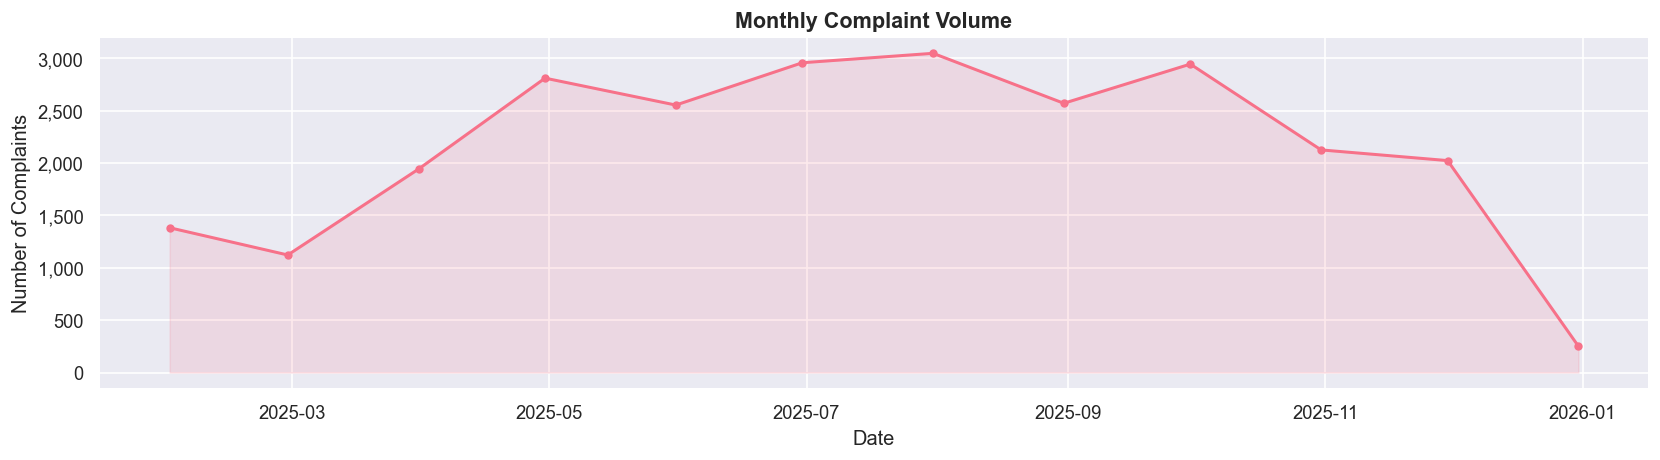

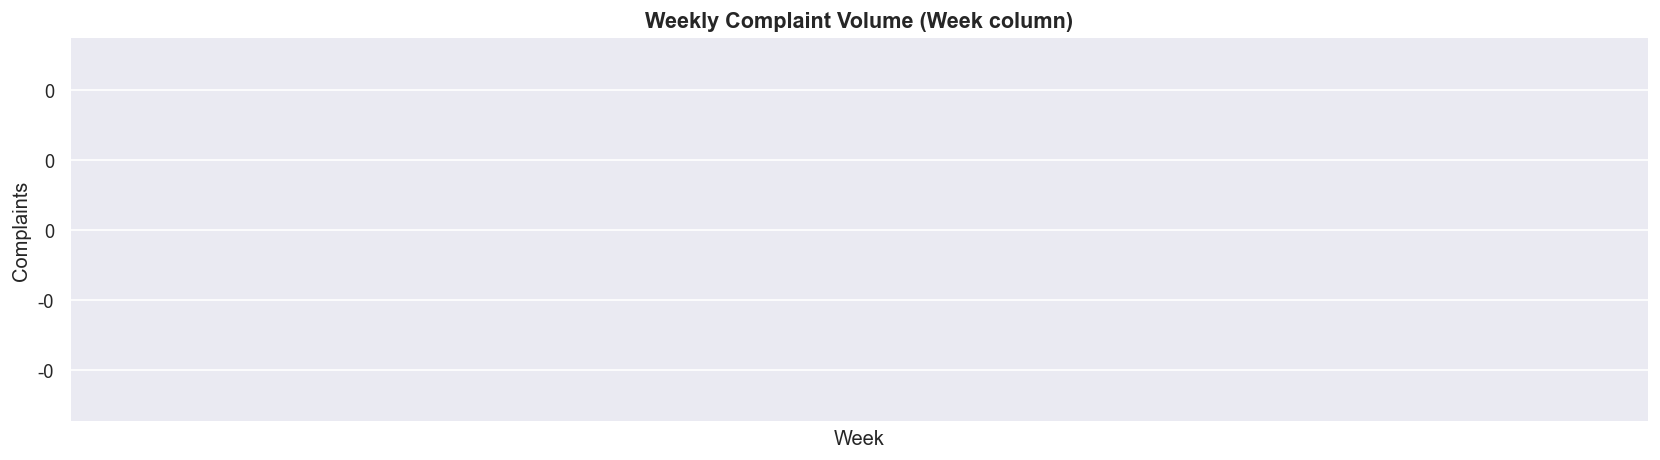

In [4]:
# ── Monthly trend ─────────────────────────────────────────────────────────
if C_TIMESTAMP in complaints.columns:
    ts = (complaints.set_index(C_TIMESTAMP)
                    .resample('ME').size()
                    .reset_index(name='count'))
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(ts[C_TIMESTAMP], ts['count'], linewidth=1.8, color=COLORS[0], marker='o', markersize=4)
    ax.fill_between(ts[C_TIMESTAMP], ts['count'], alpha=0.15, color=COLORS[0])
    ax.set_title('Monthly Complaint Volume', fontsize=13, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Number of Complaints')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    plt.tight_layout()
    plt.savefig(f'{FIGURES}/eda_complaint_volume_monthly.png', dpi=150, bbox_inches='tight')
    plt.show()

# ── Weekly trend using Week column ────────────────────────────────────────
if C_WEEK in complaints.columns and 'year' in complaints.columns:
    weekly = (complaints.groupby(['year', C_WEEK])
                        .size().reset_index(name='count'))
    weekly['label'] = (weekly['year'].astype(str) + '-W'
                       + weekly[C_WEEK].astype(str).str.zfill(2))
    weekly = weekly.sort_values(['year', C_WEEK])

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(range(len(weekly)), weekly['count'],
            linewidth=1.5, color=COLORS[2], marker='o', markersize=3)
    ax.fill_between(range(len(weekly)), weekly['count'], alpha=0.15, color=COLORS[2])
    tick_step = max(1, len(weekly) // 12)
    ax.set_xticks(range(0, len(weekly), tick_step))
    ax.set_xticklabels(weekly['label'].iloc[::tick_step], rotation=40, ha='right', fontsize=8)
    ax.set_title('Weekly Complaint Volume (Week column)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Week')
    ax.set_ylabel('Complaints')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    plt.tight_layout()
    plt.savefig(f'{FIGURES}/eda_complaint_weekly_trend.png', dpi=150, bbox_inches='tight')
    plt.show()

### 2.3 Service Type — Data vs Voice

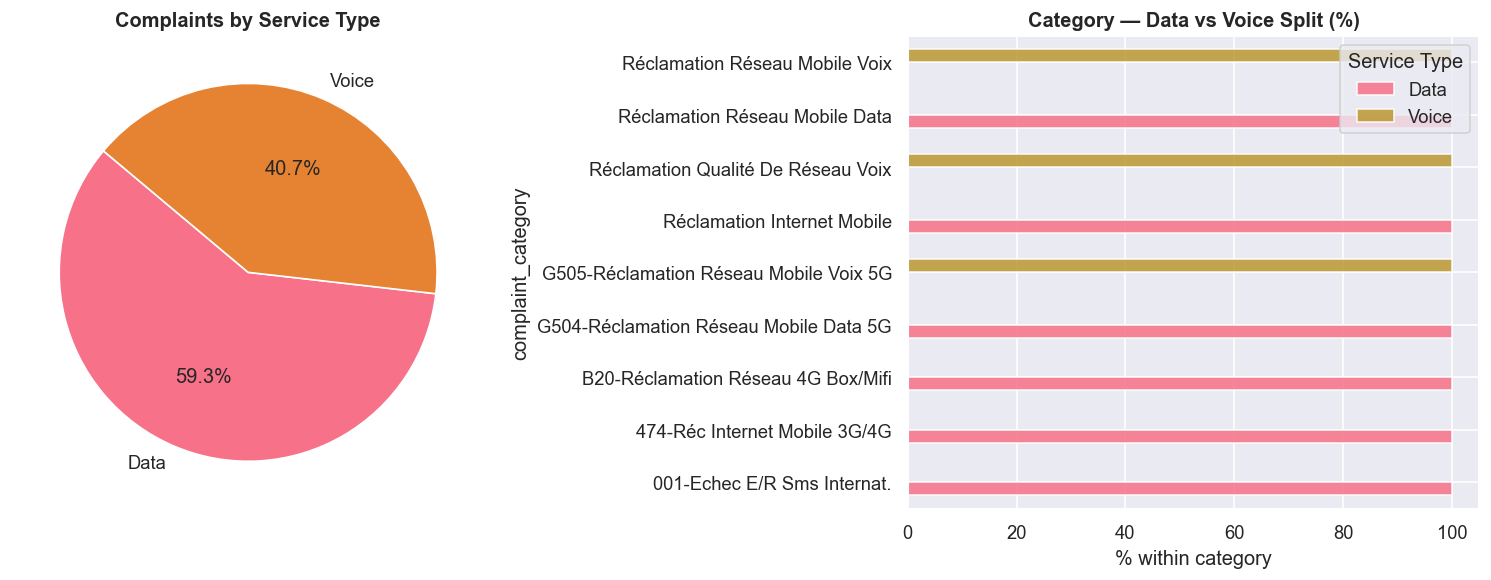


Service Type breakdown (Type column):
  Data                   15,258  (59.3%)
  Voice                  10,469  (40.7%)


In [5]:
if C_TYPE in complaints.columns:
    counts = complaints[C_TYPE].value_counts()
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Pie chart
    axes[0].pie(counts, labels=counts.index, autopct='%1.1f%%',
                colors=COLORS[:len(counts)], startangle=140)
    axes[0].set_title('Complaints by Service Type', fontsize=12, fontweight='bold')

    # Category × Type crosstab
    if C_CATEGORY in complaints.columns:
        ct = pd.crosstab(complaints[C_CATEGORY], complaints[C_TYPE],
                         normalize='index').mul(100).round(1)
        ct.plot(kind='barh', ax=axes[1],
                color=[COLORS[0], COLORS[2]][:len(ct.columns)], alpha=0.85)
        axes[1].set_title('Category — Data vs Voice Split (%)', fontsize=12, fontweight='bold')
        axes[1].set_xlabel('% within category')
        axes[1].legend(title='Service Type')

    plt.tight_layout()
    plt.savefig(f'{FIGURES}/eda_service_type.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\nService Type breakdown (Type column):')
    for svc, n in counts.items():
        print(f'  {svc:<20} {n:>8,}  ({n/len(complaints)*100:.1f}%)')
else:
    print(f'Column "{C_TYPE}" not found in dataset')

### 2.4 Complaint Category

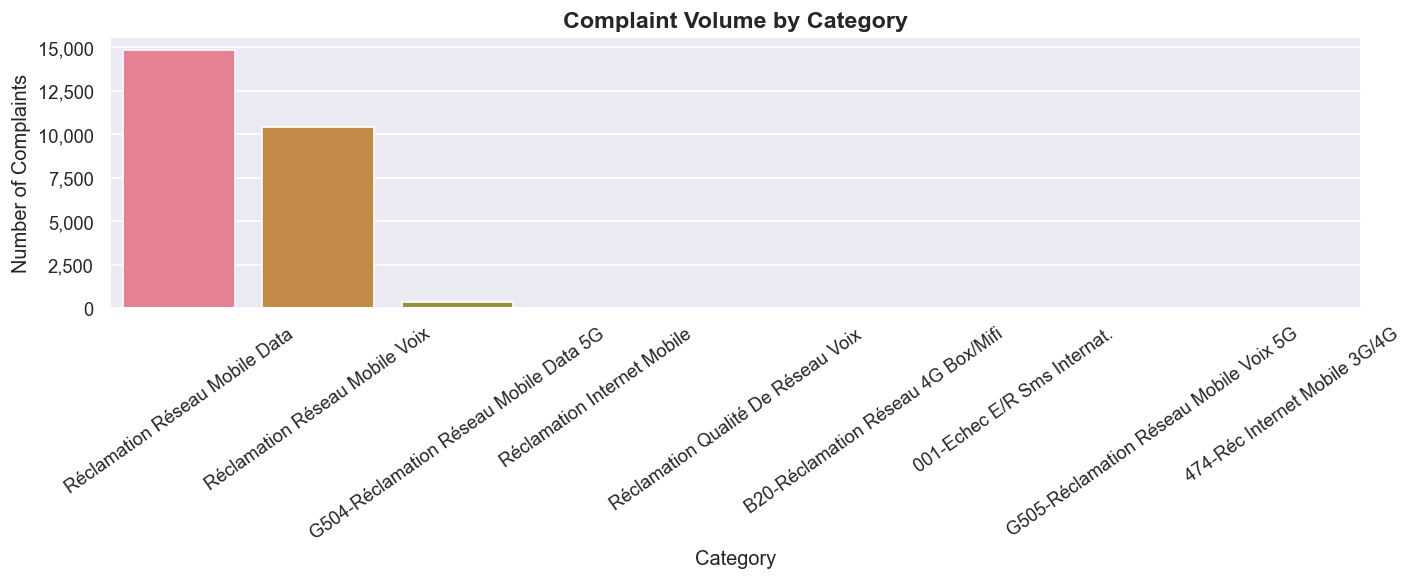


Category breakdown:
  Réclamation Réseau Mobile Data             14,841  (57.7%)
  Réclamation Réseau Mobile Voix             10,447  (40.6%)
  G504-Réclamation Réseau Mobile Data 5G        383  (1.5%)
  Réclamation Internet Mobile                    26  (0.1%)
  Réclamation Qualité De Réseau Voix             20  (0.1%)
  B20-Réclamation Réseau 4G Box/Mifi              4  (0.0%)
  001-Echec E/R Sms Internat.                     2  (0.0%)
  G505-Réclamation Réseau Mobile Voix 5G          2  (0.0%)
  474-Réc Internet Mobile 3G/4G                   2  (0.0%)


In [6]:
if C_CATEGORY in complaints.columns:
    counts = complaints[C_CATEGORY].value_counts()

    fig, ax = plt.subplots(figsize=(12, 5))
    sns.barplot(x=counts.index, y=counts.values, palette='husl', ax=ax)
    ax.set_title('Complaint Volume by Category', fontsize=14, fontweight='bold')
    ax.set_xlabel('Category')
    ax.set_ylabel('Number of Complaints')
    ax.tick_params(axis='x', rotation=35)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    plt.tight_layout()
    plt.savefig(f'{FIGURES}/eda_complaint_category.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\nCategory breakdown:')
    for cat, n in counts.items():
        print(f'  {cat:<40} {n:>8,}  ({n/len(complaints)*100:.1f}%)')
else:
    print(f'Column "{C_CATEGORY}" not found')

### 2.5 Typology — IT vs Network

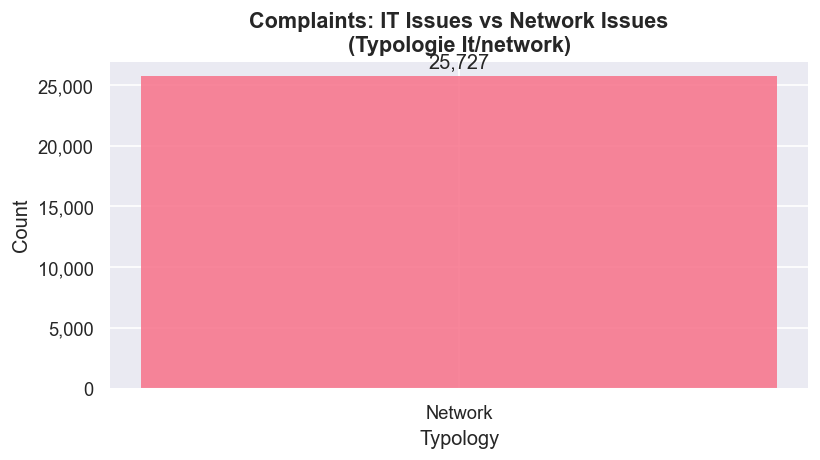

Typology breakdown (Typologie It/network):
complaint_typology
Network    25727


In [7]:
if C_TYPOLOGY in complaints.columns:
    counts = complaints[C_TYPOLOGY].value_counts()

    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(counts.index, counts.values,
                  color=[COLORS[0], COLORS[2]][:len(counts)],
                  edgecolor='none', alpha=0.85)
    ax.bar_label(bars, labels=[f'{int(v):,}' for v in counts.values], padding=3)
    ax.set_title('Complaints: IT Issues vs Network Issues\n(Typologie It/network)',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Typology')
    ax.set_ylabel('Count')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    plt.tight_layout()
    plt.savefig(f'{FIGURES}/eda_typology.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('Typology breakdown (Typologie It/network):')
    print(counts.to_string())
else:
    print(f'Column "{C_TYPOLOGY}" not found in dataset')

### 2.6 Resolution Status

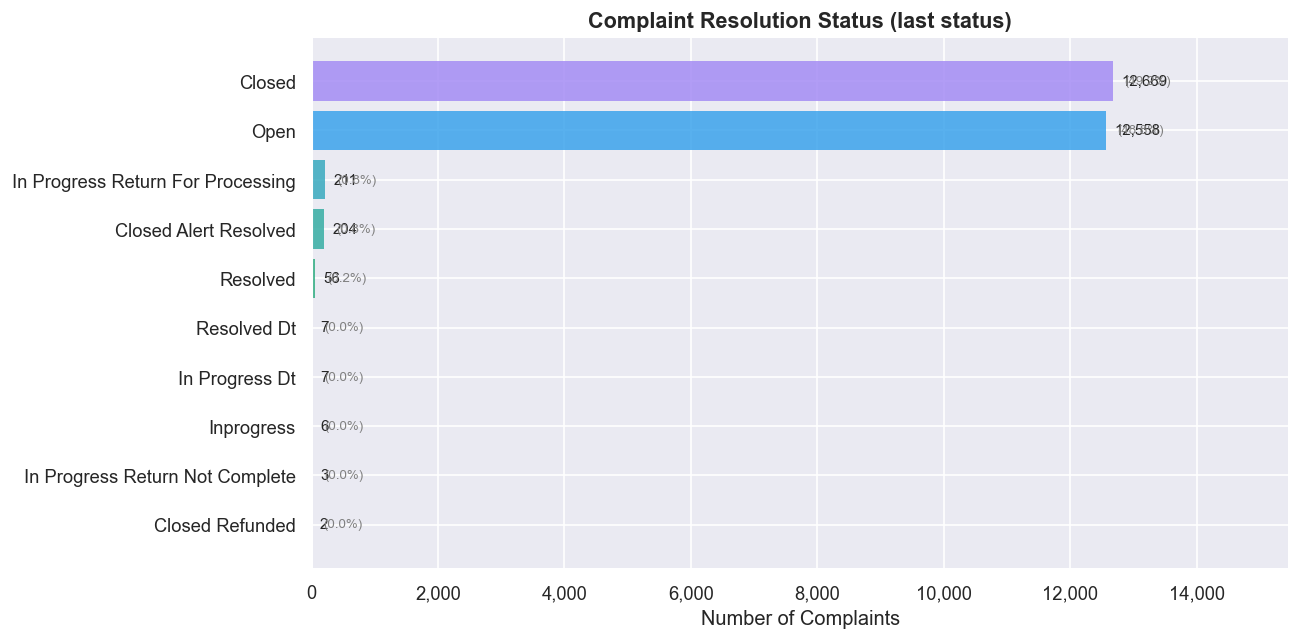

Resolution status breakdown:
  Closed                           12,669  (49.2%)
  Open                             12,558  (48.8%)
  In Progress Return For Processing      211  (0.8%)
  Closed Alert Resolved               204  (0.8%)
  Resolved                             56  (0.2%)
  In Progress Dt                        7  (0.0%)
  Resolved Dt                           7  (0.0%)
  Inprogress                            6  (0.0%)
  In Progress Return Not Complete        3  (0.0%)
  Closed Refunded                       2  (0.0%)
  Closed Dtfo                           1  (0.0%)
  In Progress Unfounded Return          1  (0.0%)
  Cancelled                             1  (0.0%)
  Reassign                              1  (0.0%)


In [8]:
if C_STATUS in complaints.columns:
    counts = (complaints[C_STATUS].value_counts()
                                  .sort_values(ascending=True)
                                  .tail(10))
    n      = len(counts)
    fig, ax = plt.subplots(figsize=(11, max(4, n * 0.55)))
    palette = [COLORS[i % len(COLORS)] for i in range(n)]
    bars = ax.barh(counts.index, counts.values, color=palette,
                   edgecolor='none', alpha=0.85)
    ax.bar_label(bars, labels=[f'{int(v):,}' for v in counts.values],
                 padding=5, fontsize=9)
    total = complaints[C_STATUS].notna().sum()
    for bar, val in zip(bars, counts.values):
        pct = val / total * 100
        ax.text(bar.get_width() + counts.values.max() * 0.015,
                bar.get_y() + bar.get_height() / 2,
                f'({pct:.1f}%)', va='center', fontsize=8, color='grey')
    ax.set_xlim(0, counts.values.max() * 1.22)
    ax.set_title('Complaint Resolution Status (last status)',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Number of Complaints')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    plt.tight_layout()
    plt.savefig(f'{FIGURES}/eda_resolution_status.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('Resolution status breakdown:')
    for s, n in complaints[C_STATUS].value_counts().items():
        print(f'  {s:<30} {n:>8,}  ({n/total*100:.1f}%)')
else:
    print(f'Column "{C_STATUS}" not found in dataset')

### 2.7 Provider Group

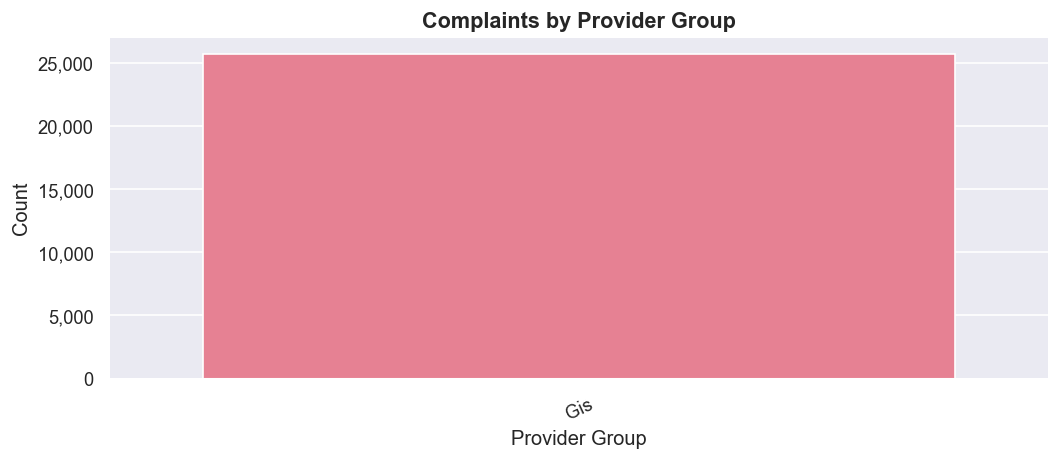

In [9]:
if C_PROVIDER in complaints.columns:
    counts = complaints[C_PROVIDER].value_counts()

    fig, ax = plt.subplots(figsize=(9, 4))
    sns.barplot(x=counts.index, y=counts.values, palette='husl', ax=ax)
    ax.set_title('Complaints by Provider Group', fontsize=13, fontweight='bold')
    ax.set_xlabel('Provider Group')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=25)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    plt.tight_layout()
    plt.savefig(f'{FIGURES}/eda_provider_group.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f'Column "{C_PROVIDER}" not found in dataset')

### 2.8 Geographic Distribution (Province & City)

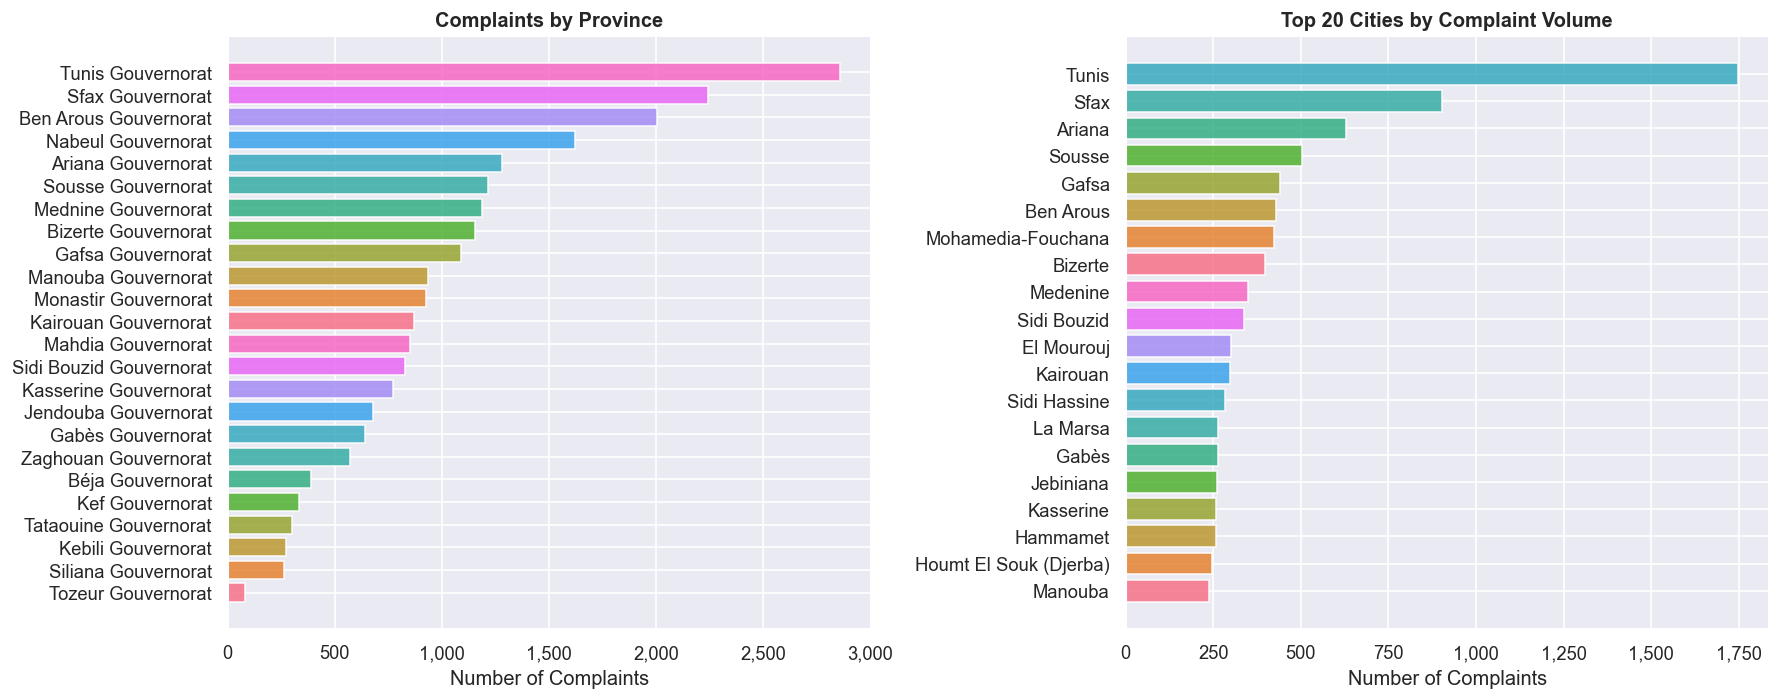

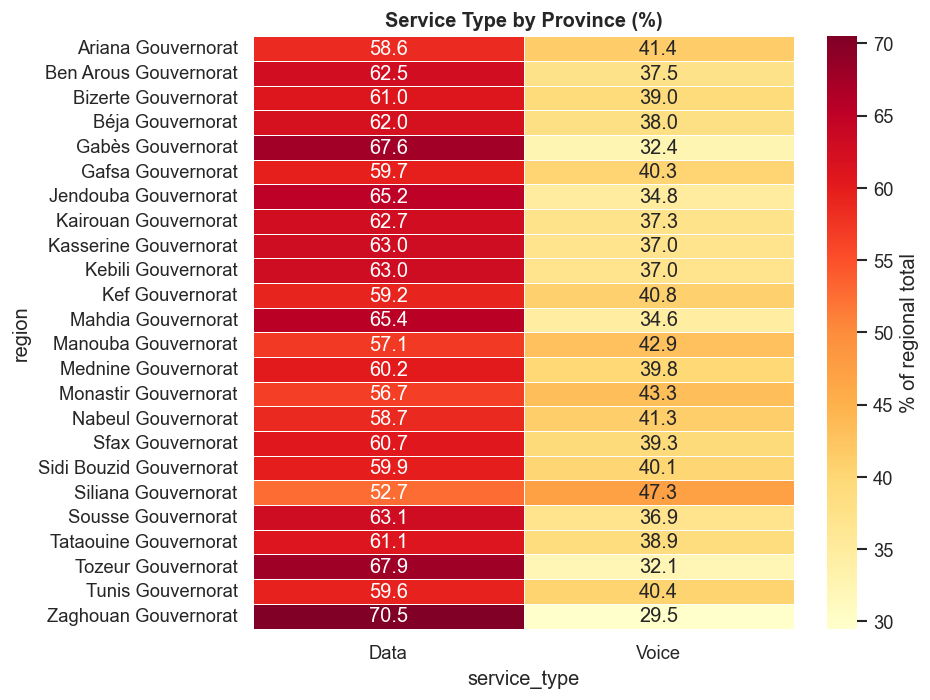

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Province
if C_PROVINCE in complaints.columns:
    prov = complaints[C_PROVINCE].value_counts().sort_values()
    axes[0].barh(prov.index, prov.values,
                 color=[COLORS[i % len(COLORS)] for i in range(len(prov))],
                 alpha=0.85)
    axes[0].set_title('Complaints by Province', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Number of Complaints')
    axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
else:
    axes[0].text(0.5, 0.5, f'"{C_PROVINCE}" not found', ha='center', va='center')

# City — top 20
if C_CITY in complaints.columns:
    city = complaints[C_CITY].value_counts().head(20).sort_values()
    axes[1].barh(city.index, city.values,
                 color=[COLORS[i % len(COLORS)] for i in range(len(city))],
                 alpha=0.85)
    axes[1].set_title('Top 20 Cities by Complaint Volume', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Number of Complaints')
    axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
else:
    axes[1].text(0.5, 0.5, f'"{C_CITY}" not found', ha='center', va='center')

plt.tight_layout()
plt.savefig(f'{FIGURES}/eda_geographic_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Province × Type heatmap
if C_PROVINCE in complaints.columns and C_TYPE in complaints.columns:
    pivot_pct = (pd.crosstab(complaints[C_PROVINCE], complaints[C_TYPE])
                   .div(complaints[C_PROVINCE].value_counts(), axis=0)
                   .mul(100).round(1))
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(pivot_pct, annot=True, fmt='.1f', cmap='YlOrRd',
                linewidths=0.3, ax=ax, cbar_kws={'label': '% of regional total'})
    ax.set_title('Service Type by Province (%)', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{FIGURES}/eda_province_service_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

### 2.9 Customer Segments (Segment MSISDN CONCERN)

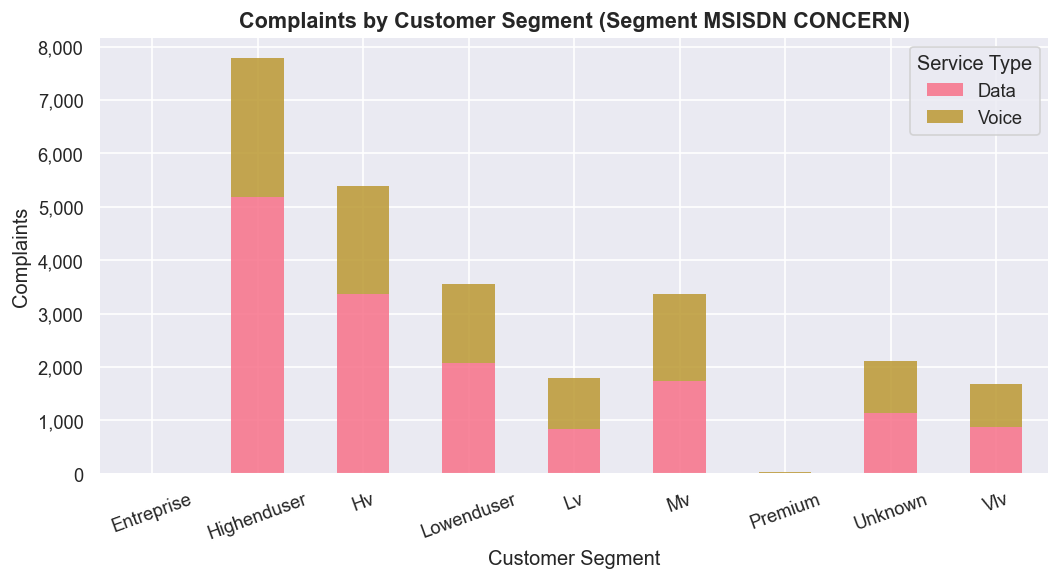

Customer segment breakdown:
customer_segment
Highenduser    7783
Hv             5388
Lowenduser     3563
Mv             3361
Unknown        2107
Lv             1802
Vlv            1686
Premium          30
Entreprise        7


In [48]:
if C_SEGMENT in complaints.columns:
    if C_TYPE in complaints.columns:
        pivot = (complaints.groupby([C_SEGMENT, C_TYPE])
                           .size().unstack(fill_value=0))
    else:
        pivot = complaints.groupby(C_SEGMENT).size().to_frame('count')

    fig, ax = plt.subplots(figsize=(9, 5))
    pivot.plot(kind='bar', ax=ax, stacked=True,
               color=[COLORS[0], COLORS[2]][:len(pivot.columns)],
               alpha=0.85, edgecolor='none')
    ax.set_title('Complaints by Customer Segment (Segment MSISDN CONCERN)',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Customer Segment')
    ax.set_ylabel('Complaints')
    ax.tick_params(axis='x', rotation=20)
    if C_TYPE in complaints.columns:
        ax.legend(title='Service Type')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    plt.tight_layout()
    plt.savefig(f'{FIGURES}/eda_customer_segment.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('Customer segment breakdown:')
    print(complaints[C_SEGMENT].value_counts().to_string())
else:
    print(f'Column "{C_SEGMENT}" not found in dataset')

### 2.10 Hour × Day of Week Heatmap

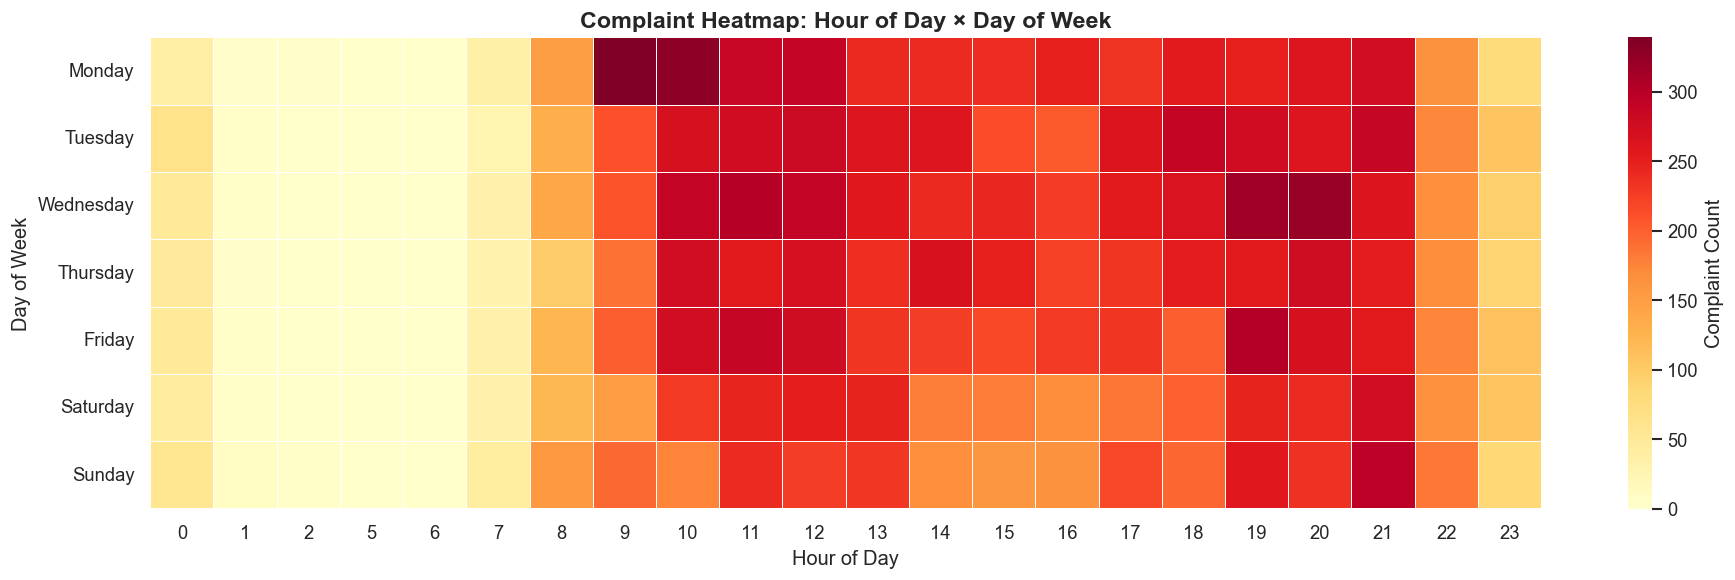

Peak hour : 19:00
Peak day  : Wednesday


In [49]:
if 'hour' in complaints.columns and 'day_of_week' in complaints.columns:
    order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
    pivot = (complaints.groupby(['day_of_week','hour'])
                       .size()
                       .unstack(fill_value=0)
                       .reindex([d for d in order if d in complaints['day_of_week'].unique()]))

    fig, ax = plt.subplots(figsize=(16, 5))
    sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.3, ax=ax,
                cbar_kws={'label': 'Complaint Count'})
    ax.set_title('Complaint Heatmap: Hour of Day × Day of Week',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Hour of Day')
    ax.set_ylabel('Day of Week')
    plt.tight_layout()
    plt.savefig(f'{FIGURES}/eda_heatmap_hour_day.png', dpi=150, bbox_inches='tight')
    plt.show()

    peak_hour = complaints['hour'].value_counts().idxmax()
    peak_day  = complaints['day_of_week'].value_counts().idxmax()
    print(f'Peak hour : {peak_hour:02d}:00')
    print(f'Peak day  : {peak_day}')
else:
    print('Derived columns hour/day_of_week not found.')
    print('Make sure case open datetime was parsed before running this cell.')

### 2.11 Sub-categories & Sub-sub-categories

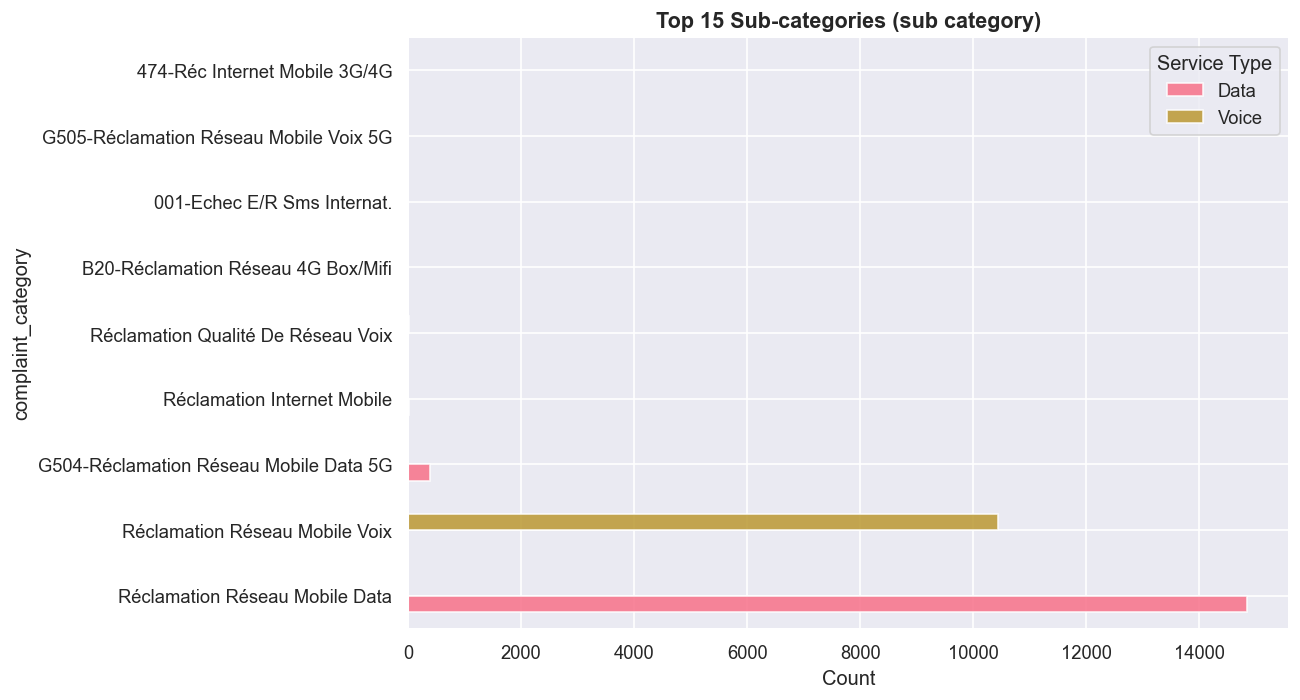

In [50]:
# ── Sub-category (top 15) ──────────────────────────────────────────────────
if C_SUBCAT in complaints.columns:
    top_vals = complaints[C_SUBCAT].value_counts().head(15).index
    sub      = complaints[complaints[C_SUBCAT].isin(top_vals)]

    if C_TYPE in complaints.columns:
        pivot = (sub.groupby([C_SUBCAT, C_TYPE])
                    .size().unstack(fill_value=0))
        fig, ax = plt.subplots(figsize=(11, 6))
        pivot.loc[[v for v in top_vals if v in pivot.index]].plot(
            kind='barh', ax=ax,
            color=[COLORS[0], COLORS[2]][:len(pivot.columns)], alpha=0.85)
        ax.legend(title='Service Type')
    else:
        counts = complaints[C_SUBCAT].value_counts().head(15).sort_values()
        fig, ax = plt.subplots(figsize=(11, 6))
        ax.barh(counts.index, counts.values, color=COLORS[0], alpha=0.85)

    ax.set_title('Top 15 Sub-categories (sub category)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Count')
    plt.tight_layout()
    plt.savefig(f'{FIGURES}/eda_subcategory_top.png', dpi=150, bbox_inches='tight')
    plt.show()

## 5. Synthetic KPI Generation <a id='5'></a>

> **Context:** The DATA and VOICE sheets currently contain only:
> `START TIME`, `MSISDN`, `Network Type`, `Type`
>
> Numeric measurement columns (throughput, latency, drop rate, etc.) are **not yet available**.
>
> **Strategy:** Generate synthetic KPIs **calibrated on your real complaints**:
> - Same regions, same date range
> - Negatively correlated with complaint spikes
> - Realistic distributions by network type (3G / 4G / 5G)
>
> Once Huawei provides the real KPI columns, replace the parquet file — all downstream notebooks automatically use the real values.

In [51]:
from src.utils.synthetic_kpi_generator import generate_all_kpi, save_synthetic_kpi

print('Generating synthetic KPI calibrated on real complaints...')
kpi_synthetic = generate_all_kpi(
    complaints,
    sessions_per_complaint=2.5,
    corr_strength=0.35,
    seed=42
)

print(f'\nShape      : {kpi_synthetic.shape}')
print(f'DATA rows  : {(kpi_synthetic["kpi_source"]=="DATA").sum():,}')
print(f'VOICE rows : {(kpi_synthetic["kpi_source"]=="VOICE").sum():,}')
print(f'Regions    : {sorted(kpi_synthetic["region"].unique())}')
print(f'Period     : {kpi_synthetic["timestamp"].min().date()} → {kpi_synthetic["timestamp"].max().date()}')
print()
print('Generated numeric KPIs:')
kpi_num = [c for c in kpi_synthetic.select_dtypes("number").columns
           if c not in ('msisdn','is_degraded_session')]
for col in kpi_num:
    print(f'  {col:<40} mean={kpi_synthetic[col].mean():.2f}')

save_synthetic_kpi(kpi_synthetic, 'data/raw/synthetic_kpi.parquet')

2026-05-04 02:56:42.026 | INFO     | src.utils.synthetic_kpi_generator:_generate:130 - Generating DATA sessions...


Generating synthetic KPI calibrated on real complaints...


2026-05-04 02:56:47.149 | INFO     | src.utils.synthetic_kpi_generator:_generate:267 -   DATA: 64,303 sessions | Good=36.9%  Fair=37.6%  Poor=25.5%
2026-05-04 02:56:47.226 | INFO     | src.utils.synthetic_kpi_generator:_generate:130 - Generating VOICE sessions...
2026-05-04 02:56:51.920 | INFO     | src.utils.synthetic_kpi_generator:_generate:267 -   VOICE: 64,341 sessions | Good=27.5%  Fair=64.6%  Poor=8.0%
2026-05-04 02:56:52.084 | SUCCESS  | src.utils.synthetic_kpi_generator:generate_all_kpi:108 - Synthetic KPI generated: 128,644 sessions  (DATA=64,303  VOICE=64,341  degraded=16.8%)



Shape      : (128644, 22)
DATA rows  : 64,303
VOICE rows : 64,341
Regions    : ['Ariana Gouvernorat', 'Ben Arous Gouvernorat', 'Bizerte Gouvernorat', 'Béja Gouvernorat', 'Gabès Gouvernorat', 'Gafsa Gouvernorat', 'Jendouba Gouvernorat', 'Kairouan Gouvernorat', 'Kasserine Gouvernorat', 'Kebili Gouvernorat', 'Kef Gouvernorat', 'Mahdia Gouvernorat', 'Manouba Gouvernorat', 'Mednine Gouvernorat', 'Monastir Gouvernorat', 'Nabeul Gouvernorat', 'Sfax Gouvernorat', 'Sidi Bouzid Gouvernorat', 'Siliana Gouvernorat', 'Sousse Gouvernorat', 'Tataouine Gouvernorat', 'Tozeur Gouvernorat', 'Tunis Gouvernorat', 'Zaghouan Gouvernorat']
Period     : 2025-01-01 → 2025-12-03

Generated numeric KPIs:
  dl_throughput_mbps                       mean=36.71
  ul_throughput_mbps                       mean=8.51
  latency_ms                               mean=68.86
  packet_loss_pct                          mean=2.82
  data_session_success_rate                mean=86.06
  data_qoe_score                           me

2026-05-04 02:56:52.803 | SUCCESS  | src.utils.synthetic_kpi_generator:save_synthetic_kpi:282 - Saved → data\raw\synthetic_kpi.parquet  (128,644 rows)


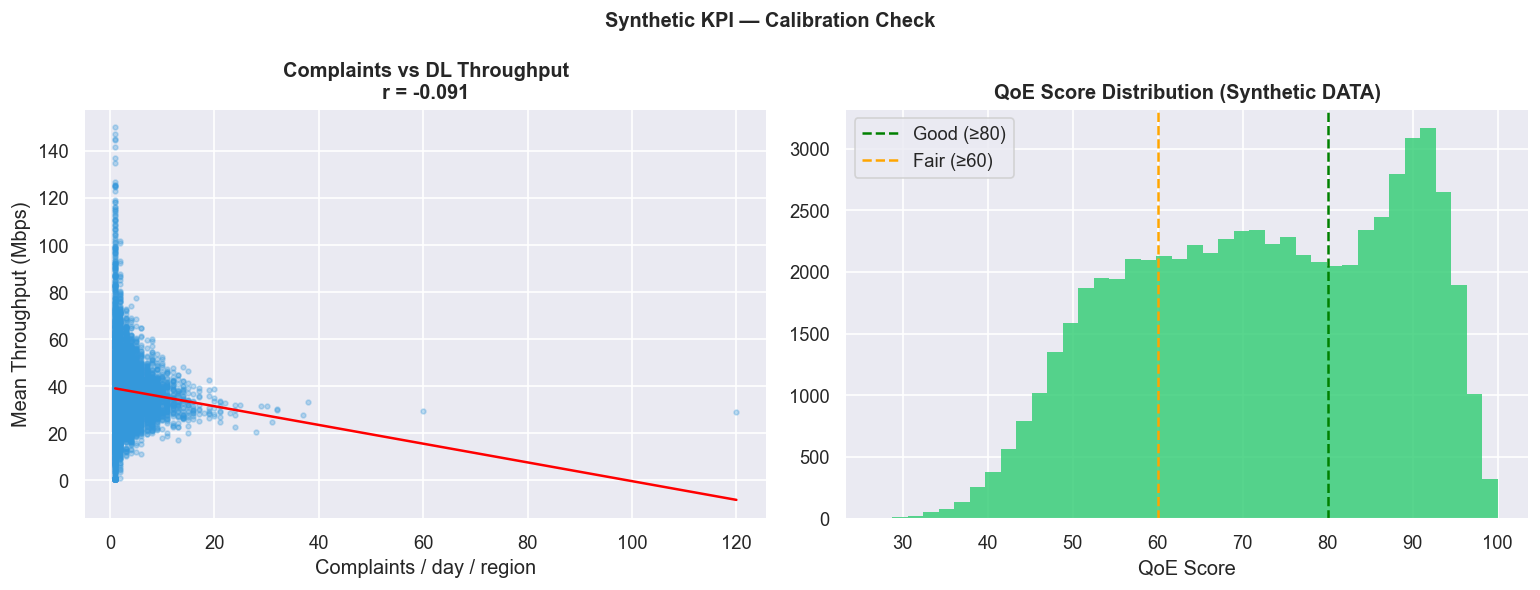

Complaint ↑ vs throughput ↓ correlation : r = -0.091


In [52]:
# ── Calibration check: complaints ↑ vs throughput ↓ ─────────────────────
daily_c = (complaints
           .groupby([C_PROVINCE, complaints[C_TIMESTAMP].dt.date.rename('date')])
           .size().reset_index(name='n_complaints'))

data_only = kpi_synthetic[kpi_synthetic['kpi_source'] == 'DATA'].copy()
daily_k   = (data_only
             .groupby(['region', data_only['timestamp'].dt.date.rename('date')])
             ['dl_throughput_mbps'].mean().reset_index(name='dl_mean'))

joined = daily_c.merge(daily_k, left_on=[C_PROVINCE, 'date'],
                                  right_on=['region',   'date'], how='inner')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(joined['n_complaints'], joined['dl_mean'],
                alpha=0.3, s=8, color='#3498db')
if len(joined) > 1:
    z  = np.polyfit(joined['n_complaints'], joined['dl_mean'], 1)
    xs = np.linspace(joined['n_complaints'].min(), joined['n_complaints'].max(), 100)
    axes[0].plot(xs, np.poly1d(z)(xs), color='red', linewidth=1.5)
r = joined['n_complaints'].corr(joined['dl_mean'])
axes[0].set_title(f'Complaints vs DL Throughput\nr = {r:.3f}', fontweight='bold')
axes[0].set_xlabel('Complaints / day / region')
axes[0].set_ylabel('Mean Throughput (Mbps)')

axes[1].hist(data_only['qoe_score'].dropna(), bins=40,
             color='#2ecc71', alpha=0.8, edgecolor='none')
axes[1].axvline(80, color='green',  linestyle='--', lw=1.5, label='Good (≥80)')
axes[1].axvline(60, color='orange', linestyle='--', lw=1.5, label='Fair (≥60)')
axes[1].set_title('QoE Score Distribution (Synthetic DATA)', fontweight='bold')
axes[1].set_xlabel('QoE Score')
axes[1].legend()

plt.suptitle('Synthetic KPI — Calibration Check', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES}/eda_synthetic_kpi_calibration.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Complaint ↑ vs throughput ↓ correlation : r = {r:.3f}')

In [53]:
print('=== EXPECTED KPI COLUMNS FROM HUAWEI ===')
expected = {
    'DATA sheet' : ['dl_throughput_mbps','ul_throughput_mbps',
                    'latency_ms','packet_loss_pct',
                    'data_session_success_rate','data_qoe_score'],
    'VOICE sheet': ['call_setup_success_rate','call_drop_rate',
                    'voice_quality_score_mos','handover_success_rate',
                    'voice_qoe_score'],
}
for sheet_name, cols in expected.items():
    print(f'\n  {sheet_name}:')
    for c in cols:
        print(f'    - {c}')

=== EXPECTED KPI COLUMNS FROM HUAWEI ===

  DATA sheet:
    - dl_throughput_mbps
    - ul_throughput_mbps
    - latency_ms
    - packet_loss_pct
    - data_session_success_rate
    - data_qoe_score

  VOICE sheet:
    - call_setup_success_rate
    - call_drop_rate
    - voice_quality_score_mos
    - handover_success_rate
    - voice_qoe_score


## 6. Data Quality Audit <a id='6'></a>

In [54]:
from src.analysis.eda import missing_value_report

print('=== SHEET1 — MISSING VALUES ===')
mv = missing_value_report(complaints, 'Sheet1')
if not mv.empty:
    display(mv)
else:
    print('  No missing values ✓')

print('\n=== DUPLICATES ===')
print(f'  Duplicate Case IDs  : {complaints[C_CASEID].duplicated().sum()}')
print(f'  Exact duplicate rows: {complaints.duplicated().sum()}')

print('\n=== MSISDN ANALYSIS ===')
print(f'  Unique MSISDNs      : {complaints[C_MSISDN].nunique():,}')
print(f'  Repeat complainants : {(complaints[C_MSISDN].value_counts() > 1).sum():,}')
top5 = complaints[C_MSISDN].value_counts().head(5)
print('  Top 5 complainants:')
for msisdn, n in top5.items():
    print(f'    {msisdn}  →  {n} complaints')

2026-05-04 02:56:55.157 | INFO     | src.analysis.eda:missing_value_report:481 - Sheet1: 4 columns with missing values


=== SHEET1 — MISSING VALUES ===


,column,missing,pct,dtype
0,week,25727,100.00,float64
1,city,2511,9.76,object
2,region,2375,9.23,object
3,customer_code,3,0.01,object



=== DUPLICATES ===
  Duplicate Case IDs  : 0
  Exact duplicate rows: 0

=== MSISDN ANALYSIS ===
  Unique MSISDNs      : 22,226
  Repeat complainants : 2,647
  Top 5 complainants:
    29378586.0  →  44 complaints
    21566820.0  →  10 complaints
    29641405.0  →  10 complaints
    26390481.0  →  8 complaints
    27984295.0  →  8 complaints


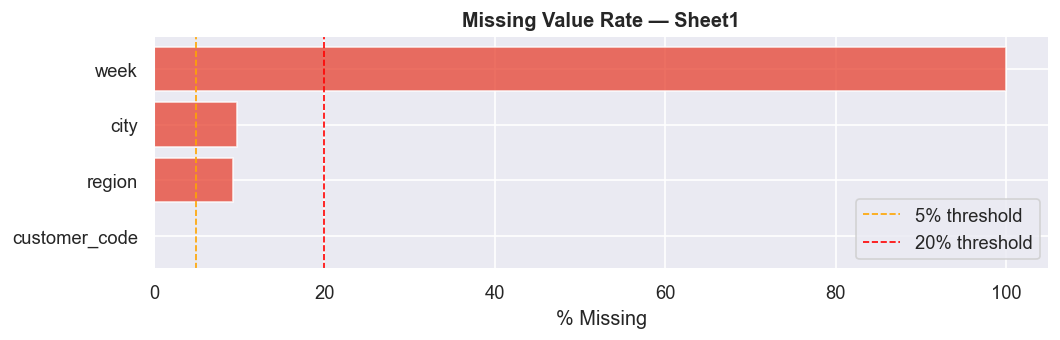

In [55]:
nulls_pct = (complaints.isnull().sum() / len(complaints) * 100)
nulls_pct = nulls_pct[nulls_pct > 0].sort_values(ascending=True)

if len(nulls_pct) > 0:
    fig, ax = plt.subplots(figsize=(9, max(3, len(nulls_pct) * 0.5)))
    ax.barh(nulls_pct.index, nulls_pct.values, color='#e74c3c', alpha=0.8)
    ax.axvline(5,  color='orange', linestyle='--', lw=1, label='5% threshold')
    ax.axvline(20, color='red',    linestyle='--', lw=1, label='20% threshold')
    ax.set_title('Missing Value Rate — Sheet1', fontweight='bold')
    ax.set_xlabel('% Missing')
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'{FIGURES}/eda_missing_values.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No missing values in main columns ✓')

## 7. EDA Summary Report <a id='7'></a>

In [56]:
import os
from pathlib import Path

# Cherche tous les parquet dans le projet
for p in Path(".").rglob("*.parquet"):
    print(p)

venv\Lib\site-packages\pyarrow\tests\data\parquet\v0.7.1.all-named-index.parquet
venv\Lib\site-packages\pyarrow\tests\data\parquet\v0.7.1.column-metadata-handling.parquet
venv\Lib\site-packages\pyarrow\tests\data\parquet\v0.7.1.parquet
venv\Lib\site-packages\pyarrow\tests\data\parquet\v0.7.1.some-named-index.parquet
venv\Lib\site-packages\altair\datasets\_metadata\metadata.parquet
src\models\anomaly\anomaly_results.parquet
src\models\clustering\dbscan_users.parquet
src\models\clustering\kmeans_users.parquet
src\models\prediction\forecasts.parquet
models\anomaly\anomaly_results.parquet
models\clustering\dbscan_users.parquet
models\clustering\kmeans_users.parquet
models\prediction\forecasts.parquet
data\processed\complaints_clean.parquet
data\processed\complaint_daily_agg.parquet
data\processed\feature_matrix.parquet
data\processed\kpi_clean.parquet
data\processed\kpi_daily_agg.parquet
data\raw\synthetic_kpi.parquet


ValueError: attempt to get argmax of an empty sequence

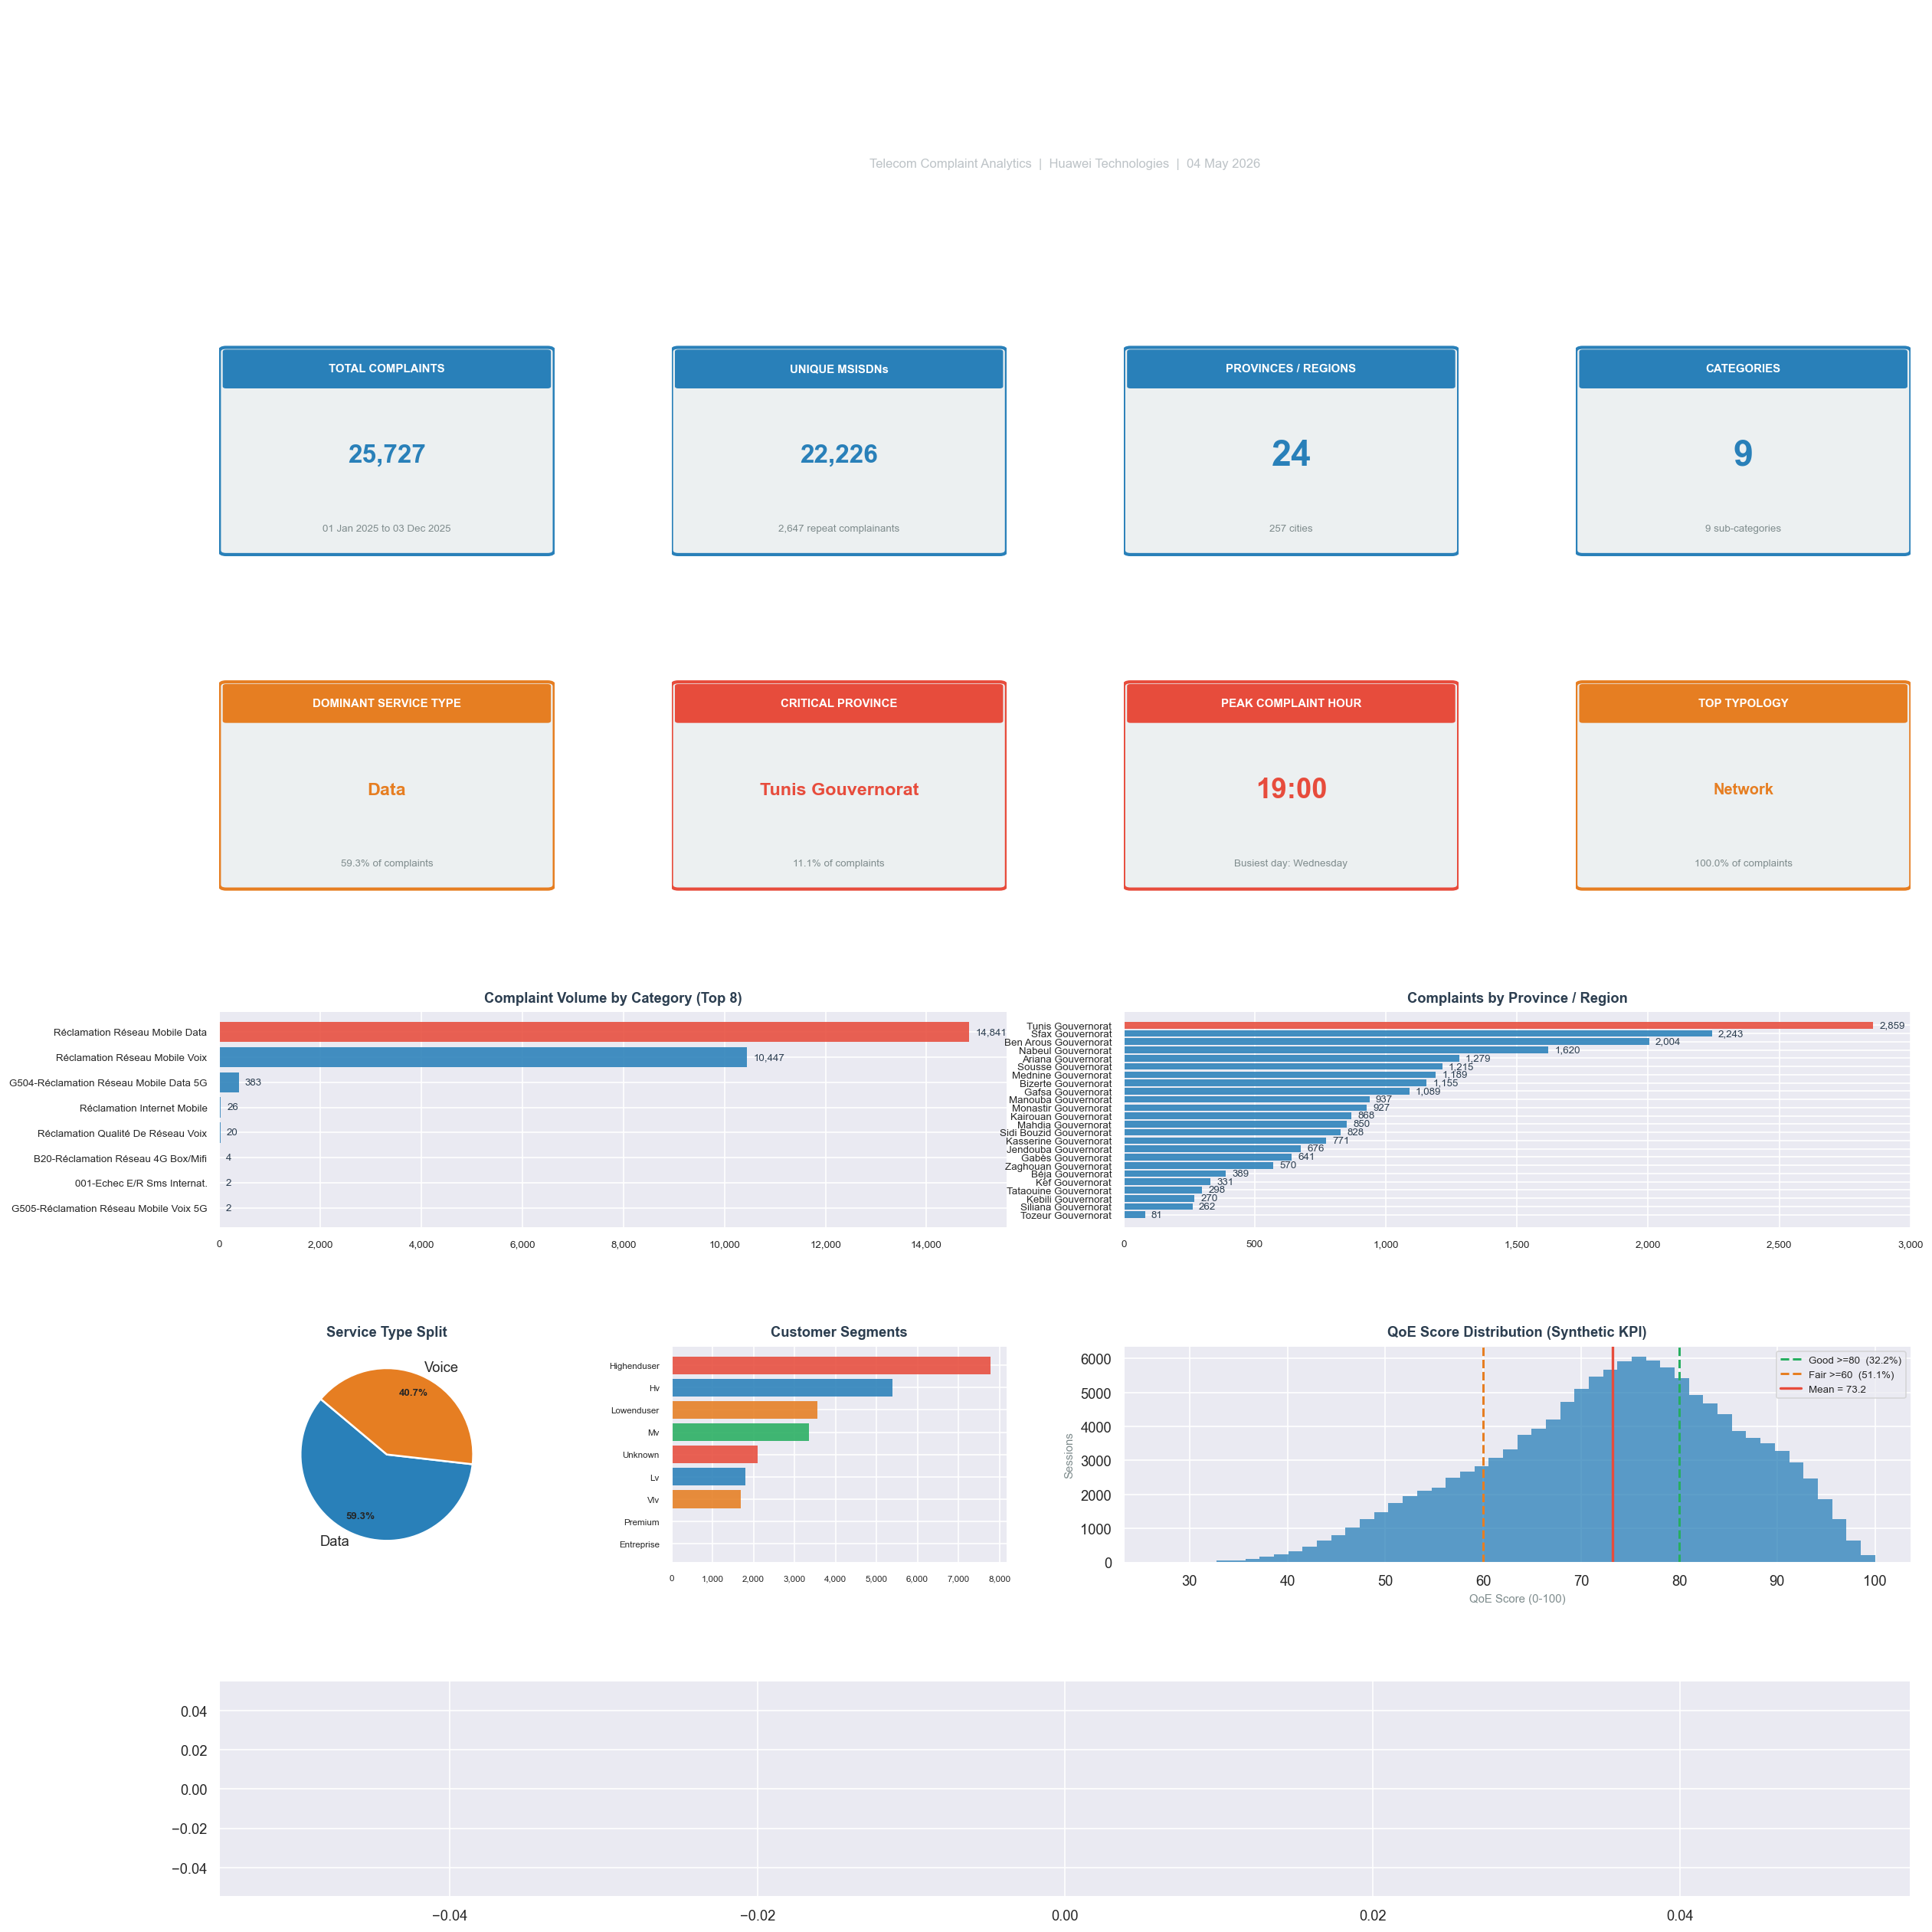

In [57]:
# ── 3. PROFESSIONAL SUMMARY FIGURE ──────────────────────────────────────
import datetime
from datetime import datetime
from matplotlib import gridspec
import matplotlib.patches as mpatches

C1='#2C3E50'; C2='#2980B9'; C3='#27AE60'; C4='#E67E22'; C5='#E74C3C'
CG='#ECF0F1'; CL='#BDC3C7'

# ── Safe metric collection (guards for missing columns) ──────────────────
total        = len(complaints)
n_msisdn     = complaints[C_MSISDN].nunique()    if C_MSISDN    else 0
repeat_msisdn= int((complaints[C_MSISDN].value_counts()>1).sum()) if C_MSISDN else 0
n_provinces  = complaints[C_PROVINCE].nunique()  if C_PROVINCE  else 0
n_cities     = complaints[C_CITY].nunique()      if C_CITY      else 0
n_categories = complaints[C_CATEGORY].nunique()  if C_CATEGORY  else 0
n_subcats    = complaints[C_SUBCAT].nunique()     if C_SUBCAT    else 0
miss_cols    = int((complaints.isnull().sum()>0).sum())
dup_ids      = int(complaints[C_CASEID].duplicated().sum()) if C_CASEID else 0

top_type     = complaints[C_TYPE].value_counts().index[0]     if C_TYPE     else 'N/A'
top_type_pct = complaints[C_TYPE].value_counts().iloc[0]/total*100 if C_TYPE else 0
top_province = complaints[C_PROVINCE].value_counts().index[0] if C_PROVINCE else 'N/A'
top_prov_pct = complaints[C_PROVINCE].value_counts().iloc[0]/total*100 if C_PROVINCE else 0
top_cat      = complaints[C_CATEGORY].value_counts().index[0] if C_CATEGORY else 'N/A'
top_cat_pct  = complaints[C_CATEGORY].value_counts().iloc[0]/total*100 if C_CATEGORY else 0
top_segment  = complaints[C_SEGMENT].value_counts().index[0]  if C_SEGMENT  else 'N/A'
top_seg_pct  = complaints[C_SEGMENT].value_counts().iloc[0]/total*100 if C_SEGMENT else 0
top_typology = complaints[C_TYPOLOGY].value_counts().index[0] if C_TYPOLOGY else 'N/A'
top_typo_pct = complaints[C_TYPOLOGY].value_counts().iloc[0]/total*100 if C_TYPOLOGY else 0

# Peak hour / day — derive from timestamp if available, else skip
if C_TIMESTAMP and C_TIMESTAMP in complaints.columns:
    complaints['_hour'] = pd.to_datetime(complaints[C_TIMESTAMP], errors='coerce').dt.hour
    complaints['_dow']  = pd.to_datetime(complaints[C_TIMESTAMP], errors='coerce').dt.day_name()
    peak_hour = int(complaints['_hour'].value_counts().idxmax())
    peak_day  = complaints['_dow'].value_counts().index[0]
elif 'hour' in complaints.columns:
    peak_hour = int(complaints['hour'].value_counts().idxmax())
    peak_day  = complaints['day_of_week'].value_counts().index[0] if 'day_of_week' in complaints.columns else 'N/A'
else:
    peak_hour = 0
    peak_day  = 'N/A'

# Period
if C_TIMESTAMP and C_TIMESTAMP in complaints.columns:
    ts = pd.to_datetime(complaints[C_TIMESTAMP], errors='coerce')
    period_from = ts.min().strftime('%d %b %Y')
    period_to   = ts.max().strftime('%d %b %Y')
else:
    period_from = 'N/A'
    period_to   = 'N/A'

# KPI metrics
good_pct = (kpi_synthetic['qoe_score'] >= 80).mean()*100
fair_pct = ((kpi_synthetic['qoe_score'] >= 60) & (kpi_synthetic['qoe_score'] < 80)).mean()*100
poor_pct = (kpi_synthetic['qoe_score'] < 60).mean()*100
mean_qoe = kpi_synthetic['qoe_score'].mean()

figures_saved = sorted([f for f in os.listdir('reports/figures') if f.startswith('eda_')])

# ── Figure layout ────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 26), facecolor='white')
gs  = gridspec.GridSpec(7, 4, figure=fig,
                        hspace=0.55, wspace=0.35,
                        top=0.96, bottom=0.03,
                        left=0.05, right=0.97)

# Header
ax_hdr = fig.add_subplot(gs[0, :])
ax_hdr.set_facecolor(C1); ax_hdr.set_xlim(0,1); ax_hdr.set_ylim(0,1); ax_hdr.axis('off')
ax_hdr.text(0.5, 0.72, 'DELIVERABLE D1 — EXPLORATORY DATA ANALYSIS REPORT',
            ha='center', va='center', fontsize=16, fontweight='bold',
            color='white', transform=ax_hdr.transAxes)
ax_hdr.text(0.5, 0.28,
            f'Telecom Complaint Analytics  |  Huawei Technologies  |  '
            f'{datetime.now().strftime("%d %B %Y")}',
            ha='center', va='center', fontsize=10,
            color='#BDC3C7', transform=ax_hdr.transAxes)

def kpi_card(ax, value, label, sublabel='', color=C2, vfs=28):
    ax.set_facecolor(CG); ax.set_xlim(0,1); ax.set_ylim(0,1); ax.axis('off')
    ax.add_patch(mpatches.FancyBboxPatch((0.02,0.04), 0.96, 0.92,
        boxstyle='round,pad=0.02', facecolor=CG, edgecolor=color, linewidth=2.5))
    ax.add_patch(mpatches.FancyBboxPatch((0.02,0.80), 0.96, 0.16,
        boxstyle='round,pad=0.01', facecolor=color, edgecolor='none'))
    ax.text(0.5, 0.88, label, ha='center', va='center',
            fontsize=9, fontweight='bold', color='white', transform=ax.transAxes)
    ax.text(0.5, 0.48, str(value), ha='center', va='center',
            fontsize=vfs, fontweight='bold', color=color, transform=ax.transAxes)
    if sublabel:
        ax.text(0.5, 0.14, sublabel, ha='center', va='center',
                fontsize=8, color='#7F8C8D', transform=ax.transAxes)

# Row 1 — dataset cards
kpi_card(fig.add_subplot(gs[1,0]), f'{total:,}',    'TOTAL COMPLAINTS',
         f'{period_from} to {period_to}', C2, 20)
kpi_card(fig.add_subplot(gs[1,1]), f'{n_msisdn:,}' if n_msisdn else 'N/A',
         'UNIQUE MSISDNs', f'{repeat_msisdn:,} repeat complainants', C2, 20)
kpi_card(fig.add_subplot(gs[1,2]), str(n_provinces), 'PROVINCES / REGIONS',
         f'{n_cities} cities' if n_cities else '', C2, 28)
kpi_card(fig.add_subplot(gs[1,3]), str(n_categories), 'CATEGORIES',
         f'{n_subcats} sub-categories' if n_subcats else '', C2, 28)

# Row 2 — insight cards
kpi_card(fig.add_subplot(gs[2,0]), top_type,     'DOMINANT SERVICE TYPE',
         f'{top_type_pct:.1f}% of complaints', C4, 14)
kpi_card(fig.add_subplot(gs[2,1]), top_province, 'CRITICAL PROVINCE',
         f'{top_prov_pct:.1f}% of complaints', C5, 14)
kpi_card(fig.add_subplot(gs[2,2]), f'{peak_hour:02d}:00', 'PEAK COMPLAINT HOUR',
         f'Busiest day: {peak_day}', C5, 22)
kpi_card(fig.add_subplot(gs[2,3]), top_typology, 'TOP TYPOLOGY',
         f'{top_typo_pct:.1f}% of complaints', C4, 12)

# Row 3 — category & province bars
ax_cat = fig.add_subplot(gs[3,:2])
if C_CATEGORY:
    cat_counts = complaints[C_CATEGORY].value_counts().head(8)
    col_bars = [C5 if i==0 else C2 for i in range(len(cat_counts))]
    bars = ax_cat.barh(cat_counts.index[::-1], cat_counts.values[::-1],
                       color=col_bars[::-1], alpha=0.88, edgecolor='none')
    ax_cat.bar_label(bars, labels=[f'{int(v):,}' for v in cat_counts.values[::-1]],
                     padding=5, fontsize=8, color=C1)
    ax_cat.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax_cat.set_title('Complaint Volume by Category (Top 8)',
                  fontsize=11, fontweight='bold', color=C1, pad=8)
ax_cat.spines[['top','right']].set_visible(False)
ax_cat.tick_params(labelsize=8)

ax_reg = fig.add_subplot(gs[3,2:])
if C_PROVINCE:
    reg_counts = complaints[C_PROVINCE].value_counts()
    col_reg = [C5 if i==0 else C2 for i in range(len(reg_counts))]
    bars2 = ax_reg.barh(reg_counts.index[::-1], reg_counts.values[::-1],
                        color=col_reg[::-1], alpha=0.88, edgecolor='none')
    ax_reg.bar_label(bars2, labels=[f'{int(v):,}' for v in reg_counts.values[::-1]],
                     padding=5, fontsize=8, color=C1)
    ax_reg.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax_reg.set_title('Complaints by Province / Region',
                  fontsize=11, fontweight='bold', color=C1, pad=8)
ax_reg.spines[['top','right']].set_visible(False)
ax_reg.tick_params(labelsize=8)

# Row 4 — pie / segment / QoE
ax_pie = fig.add_subplot(gs[4,0])
if C_TYPE:
    svc = complaints[C_TYPE].value_counts()
    wedges, texts, autotexts = ax_pie.pie(
        svc.values, labels=svc.index, autopct='%1.1f%%',
        colors=[C2,C4,C5,C3][:len(svc)], startangle=140, pctdistance=0.78,
        wedgeprops={'edgecolor':'white','linewidth':1.5})
    for t in autotexts:
        t.set_fontsize(8); t.set_fontweight('bold')
ax_pie.set_title('Service Type Split', fontsize=11, fontweight='bold', color=C1, pad=8)

ax_seg = fig.add_subplot(gs[4,1])
if C_SEGMENT:
    seg = complaints[C_SEGMENT].value_counts()
    ax_seg.barh(seg.index[::-1], seg.values[::-1],
                color=[C2,C4,C3,C5][:len(seg)][::-1], alpha=0.88, edgecolor='none')
    ax_seg.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax_seg.set_title('Customer Segments', fontsize=11, fontweight='bold', color=C1, pad=8)
ax_seg.spines[['top','right']].set_visible(False)
ax_seg.tick_params(labelsize=7)

ax_qoe = fig.add_subplot(gs[4,2:])
qoe_vals = kpi_synthetic['qoe_score'].dropna()
ax_qoe.hist(qoe_vals, bins=50, color=C2, alpha=0.75, edgecolor='none')
ax_qoe.axvline(80, color=C3, linestyle='--', lw=1.8,
               label=f'Good >=80  ({good_pct:.1f}%)')
ax_qoe.axvline(60, color=C4, linestyle='--', lw=1.8,
               label=f'Fair >=60  ({fair_pct:.1f}%)')
ax_qoe.axvline(mean_qoe, color=C5, linestyle='-', lw=2,
               label=f'Mean = {mean_qoe:.1f}')
ax_qoe.set_title('QoE Score Distribution (Synthetic KPI)',
                  fontsize=11, fontweight='bold', color=C1, pad=8)
ax_qoe.set_xlabel('QoE Score (0-100)', fontsize=9, color='#7F8C8D')
ax_qoe.set_ylabel('Sessions', fontsize=9, color='#7F8C8D')
ax_qoe.legend(fontsize=8, framealpha=0.7)
ax_qoe.spines[['top','right']].set_visible(False)

# Row 5 — weekly trend (robust: no 'year' column required)
ax_ts = fig.add_subplot(gs[5,:])
if C_WEEK and C_WEEK in complaints.columns:
    if 'year' in complaints.columns:
        weekly = (complaints.groupby(['year', C_WEEK])
                            .size().reset_index(name='count')
                            .sort_values(['year', C_WEEK]))
        weekly['label'] = (weekly['year'].astype(str) + '-W'
                           + weekly[C_WEEK].astype(str).str.zfill(2))
    else:
        # No year column — group by week number only
        weekly = (complaints.groupby(C_WEEK)
                            .size().reset_index(name='count')
                            .sort_values(C_WEEK))
        weekly['label'] = 'W' + weekly[C_WEEK].astype(str).str.zfill(2)

    ax_ts.plot(range(len(weekly)), weekly['count'],
               color=C2, linewidth=1.8, zorder=3)
    ax_ts.fill_between(range(len(weekly)), weekly['count'],
                       alpha=0.15, color=C2)
    peak_idx = weekly['count'].idxmax()
    peak_pos = weekly.index.get_loc(peak_idx)
    ax_ts.annotate(
        f"Peak: {int(weekly.loc[peak_idx,'count']):,}",
        xy=(peak_pos, weekly.loc[peak_idx,'count']),
        xytext=(10, 12), textcoords='offset points',
        fontsize=8, color=C5,
        arrowprops=dict(arrowstyle='->', color=C5, lw=1.2)
    )
    tick_step = max(1, len(weekly)//14)
    ax_ts.set_xticks(range(0, len(weekly), tick_step))
    ax_ts.set_xticklabels(weekly['label'].iloc[::tick_step],
                          rotation=35, ha='right', fontsize=7)
else:
    ax_ts.text(0.5, 0.5, 'Week column not available',
               ha='center', va='center', fontsize=11, color='#7F8C8D',
               transform=ax_ts.transAxes)

ax_ts.set_title('Weekly Complaint Volume Trend',
                 fontsize=11, fontweight='bold', color=C1, pad=8)
ax_ts.set_ylabel('Complaints', fontsize=9, color='#7F8C8D')
ax_ts.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax_ts.spines[['top','right']].set_visible(False)
ax_ts.grid(axis='y', alpha=0.3)

# Row 6 — quality + next steps
dq_color  = C3 if miss_cols==0 and dup_ids==0 else C4
dq_status = 'PASS  OK' if miss_cols==0 and dup_ids==0 else 'ACTION REQUIRED'

for col_idx, (title, color_border, lines) in enumerate([
    ('DATA QUALITY AUDIT', dq_color, [
        (f'Overall Status       : {dq_status}',               10, dq_color, 'bold',   0.76),
        (f'Missing value columns: {miss_cols}',                 9, C1,      'normal', 0.62),
        (f'Duplicate Case IDs   : {dup_ids}',                   9, C1,      'normal', 0.50),
        (f'Duplicate rows       : {complaints.duplicated().sum()}', 9, C1,  'normal', 0.38),
        (f'Repeat complainants  : {repeat_msisdn:,}',           9, C1,      'normal', 0.26),
        ('Sweetviz : reports/sweetviz/',                        8, '#7F8C8D','normal', 0.12),
    ]),
    ('NEXT STEPS — NOTEBOOK 02', C2, [
        ('Cleaning & Feature Engineering',                     10, C2,      'bold',   0.76),
        ('Standardise category / sub-category values',          9, C1,      'normal', 0.63),
        ('Engineer lag features (t-1, t-7)',                    9, C1,      'normal', 0.51),
        ('Rolling KPI windows (7d, 30d)',                       9, C1,      'normal', 0.39),
        ('Build MSISDN join key for KPI merge',                 9, C1,      'normal', 0.27),
        ('Replace synthetic KPI when Huawei data arrives',      8, '#7F8C8D','normal', 0.13),
    ]),
]):
    ax_p = fig.add_subplot(gs[6, col_idx*2 : col_idx*2+2])
    ax_p.set_facecolor(CG); ax_p.axis('off')
    ax_p.add_patch(mpatches.FancyBboxPatch((0.01,0.01), 0.98, 0.98,
        boxstyle='round,pad=0.02', facecolor=CG,
        edgecolor=color_border, linewidth=1.5))
    ax_p.text(0.05, 0.90, title, fontsize=12, color=C1, fontweight='bold',
              transform=ax_p.transAxes, va='center')
    for text, fs, col, fw, y in lines:
        ax_p.text(0.05, y, text, fontsize=fs, color=col, fontweight=fw,
                  transform=ax_p.transAxes, va='center')

# Footer
fig.text(0.5, 0.005,
         f'PFE Master Engineering  |  Huawei Technologies  |  '
         f'{datetime.now().strftime("%d %B %Y")}  |  '
         f'Source: real_complaints.xlsx  |  {total:,} records  |  D1/7',
         ha='center', fontsize=8, color='#95A5A6')

out_path = 'reports/figures/D1_EDA_Summary_Report.png'
fig.savefig(out_path, dpi=180, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print(f'Report saved: {out_path}')